## Sherlock illustration
### To run this notebook, please [follow the instructions](https://lasair-lsst.readthedocs.io/en/main/core_functions/python-notebooks.html) or else it won`t work.
The instructions are at https://lasair-lsst.readthedocs.io/en/main/core_functions/python-notebooks.html

In this notebook, we use the Lasair API to invoke Sherlock, 
to find the likely host galaxy if there were an alert there. It shows how there can be
multiple possible matches, including repeats, but Sherlock chooses the best one.

*IMPORTANT*: this notebook is to explain how Sherlock works. Lasair computes the Sherlock
crossmatch for every alert anyway, so you need not call the API, but rather use the
table supplied in the filter builder.

In [7]:
import os, sys, json
import matplotlib.pyplot as plt
import lasair

In [8]:
API_TOKEN = os.getenv('LASAIR_LSST_TOKEN')
if API_TOKEN is None:
    print("No Token found. Check Spelling. Note that if you have just added your token to your environment variables, you may need to restart your terminal so your shell settings are reloaded. ")
    
endpoint='https://api.lasair.lsst.ac.uk/api'
L = lasair.lasair_client(API_TOKEN, endpoint=endpoint)

In [9]:
# Carefully chosen sky point near four galaxies
ra = 150.096944
dec =  1.636908

In [10]:
# If `lite=True` (the default), you just get the best guess rather than all possible crossmatches
sherl = L.sherlock_position(ra, dec, lite=False)
print(json.dumps(sherl, indent=2))

{
  "classifications": {
    "query0": [
      "VS",
      "The transient is synonymous with <em><a href=\"http://skyserver.sdss.org/dr12/en/tools/explore/Summary.aspx?id=1237651753460367864\">SDSS J100023.30+013812.9</a></em>; a G=19.79 mag stellar source found in the SDSS/GAIA/PS1 catalogues. It's located 0.5\" from the stellar source core."
    ]
  },
  "crossmatches": [
    {
      "G": 19.7936,
      "_g": 21.116600036621094,
      "_gErr": 0.01735999993979931,
      "_i": 19.254199981689453,
      "_iErr": 0.00978699978441,
      "_r": 19.924299240112305,
      "_rErr": 0.006802000105381012,
      "_u": 23.1765,
      "_uErr": 0.813994,
      "_y": 18.937400817871094,
      "_yErr": 0.02975199930369854,
      "_z": 19.087400436401367,
      "_zErr": 0.014708000235259533,
      "association_type": "VS",
      "best_distance": null,
      "best_distance_flag": null,
      "best_distance_source": null,
      "catalogue_object_id": "1237651753460367864",
      "catalogue_object_subty

### All the crossmatches
First is sherlock's opinion of this match (lower rank is better), 
then the delta position in arcseconds from the given position,
then the catalogue from which the object came.

In [11]:
size = 50
elist = [0.0]
nlist = [0.0]
slist = [size]
print('rank  east arcsec  north arcsec catalogue')
for cm in sherl['crossmatches']:
    if not 'rank' in cm: continue
    e =  float(cm['eastSeparationArcsec'])
    n = -float(cm['northSeparationArcsec'])
    print('%2s      %8.2f %8.2f          %s' % (cm['rank'], e, n, cm['catalogue_table_name']))
    elist.append(e)
    nlist.append(n)
    slist.append(size/int(cm['rank'] + 1))

rank  east arcsec  north arcsec catalogue
 1          0.51    -0.07          SDSS/GAIA/PS1


We can plot the alert (centre) and the various crossmatches found by Sherlock.
The largest symbol (rank=1) is where Sherlock decides is the correct host galaxy for this alert.

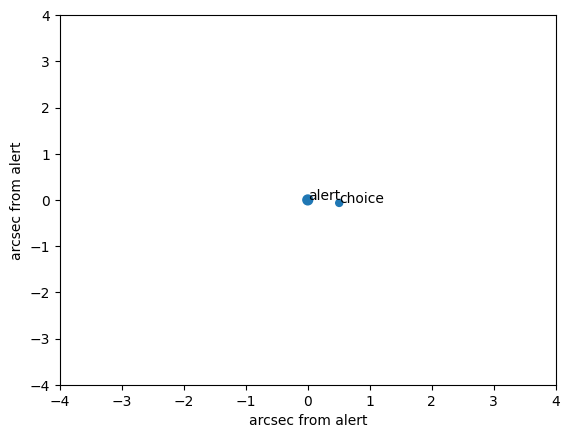

In [12]:
plt.scatter(elist, nlist, s=slist)
plt.xlim((-4, 4)) 
plt.ylim((-4, 4)) 
plt.xlabel('arcsec from alert')
plt.ylabel('arcsec from alert')
plt.annotate('alert', (0,0))
plt.annotate('choice', (elist[1],nlist[1]))
plt.show()